In [ ]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import duckdb
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd
import numpy as np

In [3]:
plt.style.use(['science','no-latex', 'ieee'])

In [31]:
GAME = "Breakout"
FILES = ["baseline", "median", "diffusion_naive", "diffusion_full"]
EXTENSION = f"_{GAME.lower()}.csv"
DIR = os.path.join("..", "results", "rl")
COLUMNS = ["length", "reward", "sigma_noise", "setup"]
OUT_CSV = os.path.join(DIR, f"{GAME.lower()}.csv")
OUT_SVG = os.path.join(DIR, f"{GAME.lower()}.svg")

In [32]:
ceil_file = os.path.join(DIR, "reproduce" + EXTENSION)
files = list(map(lambda x: os.path.join(DIR, x + EXTENSION), FILES))

In [33]:
ceil = pd.read_csv(ceil_file)
data = pd.concat([pd.read_csv(file) for file in files])

In [34]:
ceil = ceil[COLUMNS]
ceil = duckdb.sql("""
                  SELECT setup, sigma_noise, MEAN(reward) AS avg_reward, MEAN(length) AS avg_length
                  FROM ceil GROUP BY setup, sigma_noise ORDER BY sigma_noise ASC
                  """).to_df()

In [35]:
data = data[COLUMNS]

In [36]:
grouped = duckdb.sql("""
                     SELECT setup, sigma_noise, MEAN(reward) AS avg_reward, MEAN(length) AS avg_length
                     FROM data GROUP BY setup, sigma_noise
                     """).to_df()

In [37]:
baseline = duckdb.sql("SELECT avg_reward, avg_length FROM grouped WHERE setup == 'baseline' ORDER BY sigma_noise ASC").to_df()
median = duckdb.sql("SELECT avg_reward, avg_length FROM grouped WHERE setup == 'median' ORDER BY sigma_noise ASC").to_df()
diffusion_naive = duckdb.sql("SELECT avg_reward, avg_length FROM grouped WHERE setup == 'diffusion_naive' ORDER BY sigma_noise ASC").to_df()
diffusion_full = duckdb.sql("SELECT avg_reward, avg_length FROM grouped WHERE setup == 'diffusion_full' ORDER BY sigma_noise ASC").to_df()

sigmas = data["sigma_noise"].unique()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


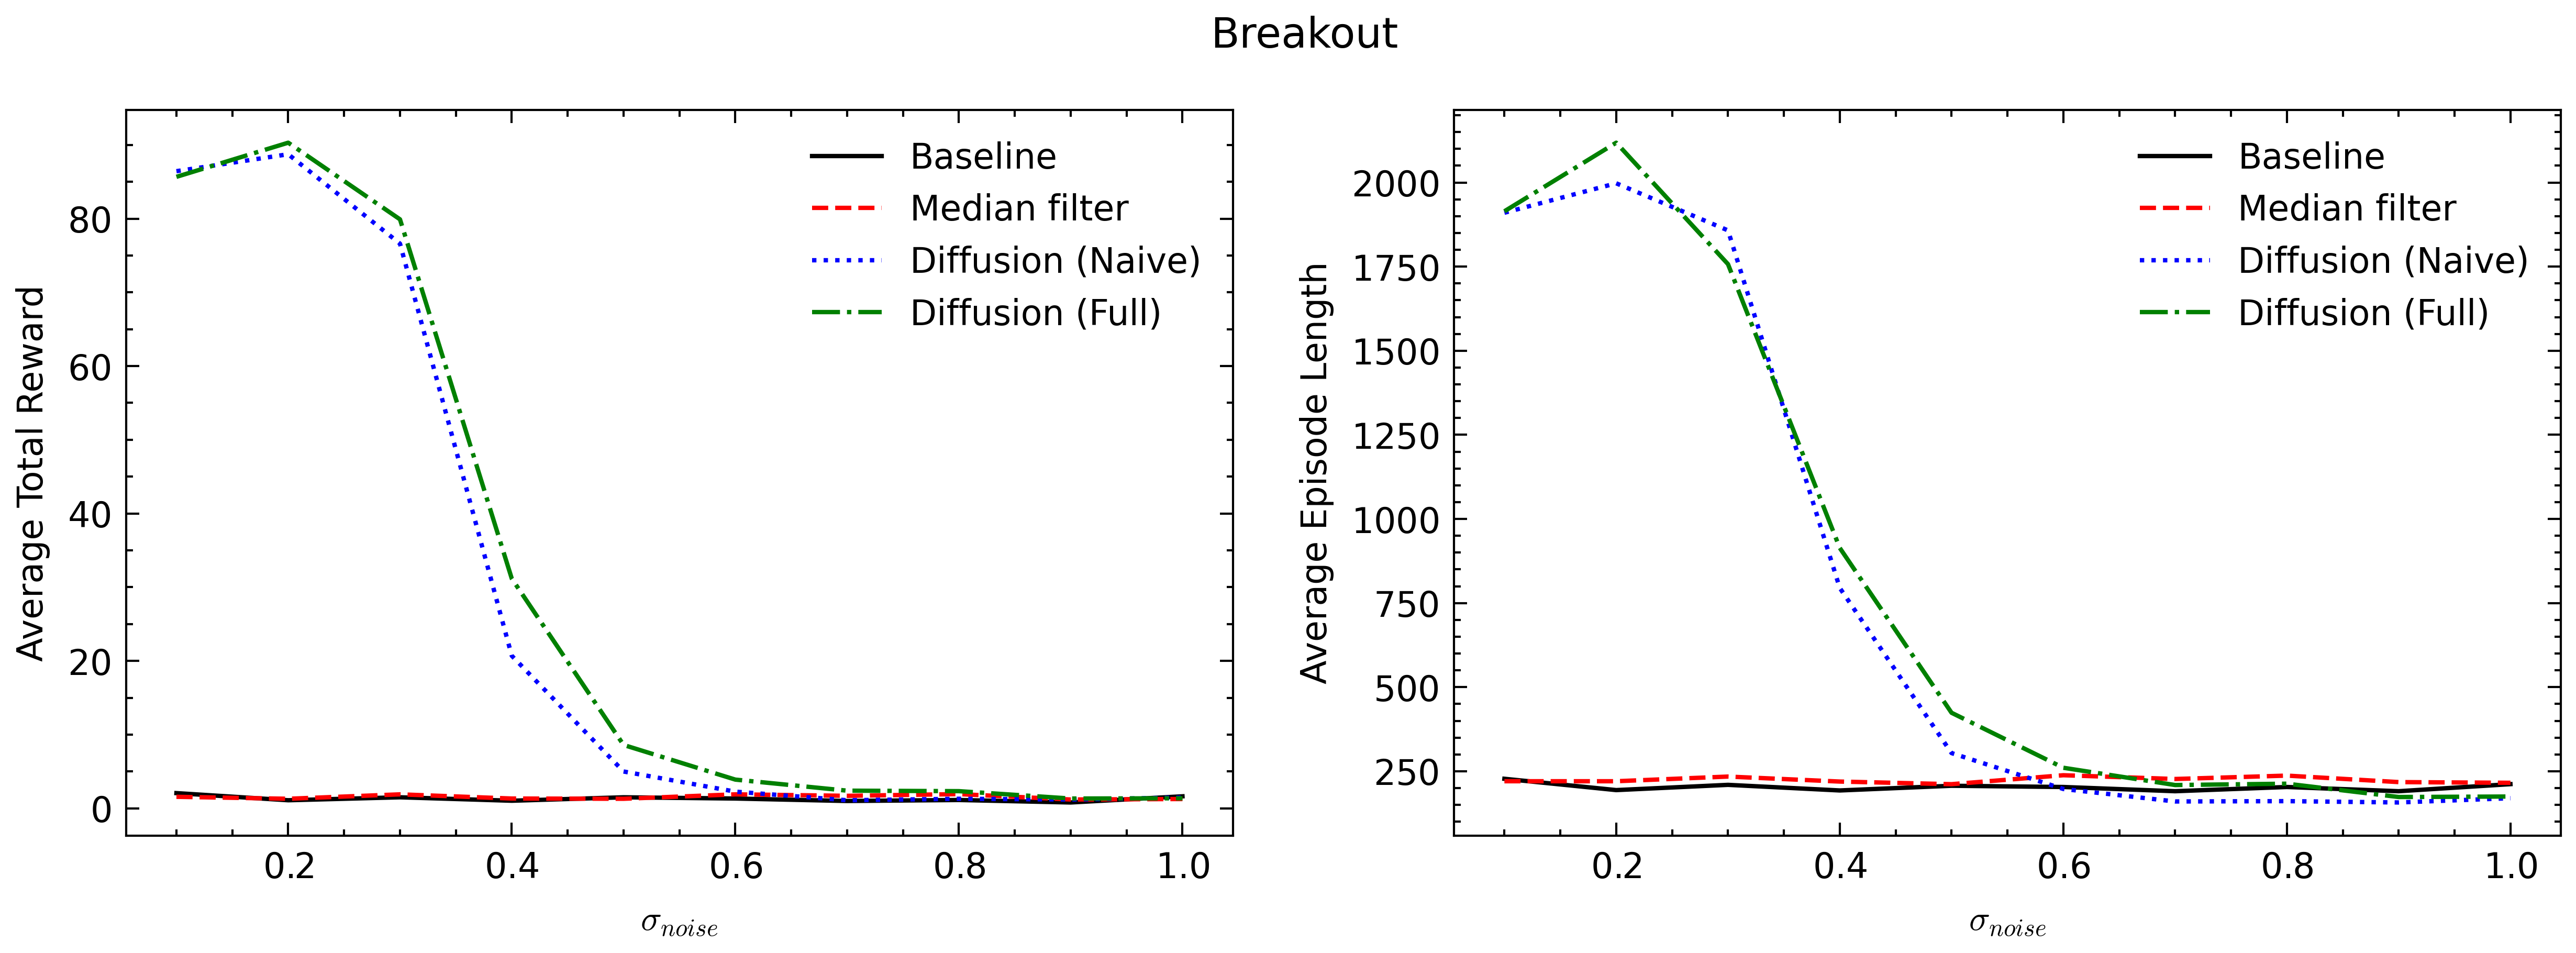

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 3))

axis[0].plot(sigmas, baseline["avg_reward"].to_numpy(), label="Baseline")
axis[0].plot(sigmas, median["avg_reward"].to_numpy(), label="Median filter")
axis[0].plot(sigmas, diffusion_naive["avg_reward"].to_numpy(), label="Diffusion (Naive)")
axis[0].plot(sigmas, diffusion_full["avg_reward"].to_numpy(), label="Diffusion (Full)")

axis[0].set_ylabel("Average Total Reward")
axis[0].set_xlabel("$\\sigma_{noise}$")

# axis[0].set_title("Average total reward")

axis[0].grid()
axis[0].legend()

axis[1].plot(sigmas, baseline["avg_length"].to_numpy(), label="Baseline")
axis[1].plot(sigmas, median["avg_length"].to_numpy(), label="Median filter")
axis[1].plot(sigmas, diffusion_naive["avg_length"].to_numpy(), label="Diffusion (Naive)")
axis[1].plot(sigmas, diffusion_full["avg_length"].to_numpy(), label="Diffusion (Full)")

axis[1].set_ylabel("Average Episode Length")
axis[1].set_xlabel("$\\sigma_{noise}$")

# axis[1].set_title("Average episode length")

axis[1].grid()
axis[1].legend()

fig.suptitle(GAME)

plt.savefig(OUT_SVG)
plt.show()

In [39]:
out = duckdb.sql("""
                 SELECT * FROM grouped
                 UNION BY NAME
                 SELECT * FROM ceil
                 """).to_df()
out = duckdb.sql("""SELECT * FROM out ORDER BY setup, sigma_noise ASC""").to_df()
out.to_csv(OUT_CSV)